# Yeongdeok 2025 — retrospective validation with real terrain + baselines
# 영덕 2025 산불 후향적 검증 — 실제 지형 + 베이스라인 비교

**Session 3 deliverable**. This notebook runs the WildfireGuardian cellular automaton
against the March 22 – 28, 2025 영덕군 wildfire event using:

| Input | Status | Source |
|-------|--------|--------|
| Digital Elevation Model | **REAL** | NASA SRTMGL1 (30 m), via AWS Mapzen archive |
| Fuel-type raster | SYNTHETIC | 100% Korean Pinus densiflora analog (KFS 임상도 pending) |
| Wind time series | SYNTHETIC | reconstruction of March 22-28 2025 양강지풍 from PUBLIC reports |
| Observed perimeter | APPROXIMATE | wind-aligned ellipse reconstruction from public reporting (KFS shapefile pending) |
| LFMC | ASSUMED | 40 % (KFS post-event field estimate) |
| Korean Pinus fuel parameters | ANALOG | adapted from FM10 (Korean field data pending) |

We compare three predictions to the approximate observed perimeter at horizons 1 h, 3 h, 6 h, 24 h:

1. **Our model** — multi-class Rothermel + Korean Pinus + Huygens-elliptical CA over real SRTM terrain.
2. **Persistence baseline** — fire never grows beyond the ignition cell.
3. **Isotropic baseline** — fire grows as a perfect circle at the mean head-fire rate (wind-ignorant).

**Honest framing**: with synthetic fuel + synthetic wind + approximate observed, the
absolute IoU numbers should be read as *order-of-magnitude*, not high-precision validation.
What we can defensibly claim from this notebook is the *relative ordering*: does our
model beat the naive baselines?


In [1]:
from datetime import date, datetime
from pathlib import Path

import numpy as np

from wildfireguardian.utils.regions import YEONGDEOK_2025
from wildfireguardian.validation import (
    ModelConfig, load_case, run_validation_with_baselines,
)
from wildfireguardian.data_io.weather import load_aws_wind
from wildfireguardian.data_io.raster import load_dem

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
case = load_case(repo_root / "data" / "validation_cases" / "yeongdeok_2025.json")
print(f"Case region:  {case.region.name}")
print(f"Ignition:     {case.observed_ignition_point_wgs84}  (영덕군 영해면, public-reported)")
print(f"Observed:     {case.observed_perimeters_path}")
print(f"Provenance:   {case.notes[:100]}...")

Case region:  yeongdeok_2025
Ignition:     (129.37, 36.5)  (영덕군 영해면, public-reported)
Observed:     data/validation_cases/yeongdeok_2025_perimeter_approx.geojson
Provenance:   March 22-28, 2025 wildfire event in 영덕군 (Yeongdeok-gun), Gyeongsangbuk-do. ~3,800 ha burned per KFS ...


DEM source:        srtm
DEM synthetic?:    False
DEM citation:      NASA JPL (2013). NASA Shuttle Radar Topography Mission Global 1 arc second [SRTMGL1] V003. NASA EOSDIS Land Processes DAAC. doi:10.5067/MEaSUREs/SRTM/SRTMGL1.003
DEM range:         0 - 820 m
DEM mean:          104 m (low because part of bbox is East Sea)


/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/2982348705.py:17: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG})

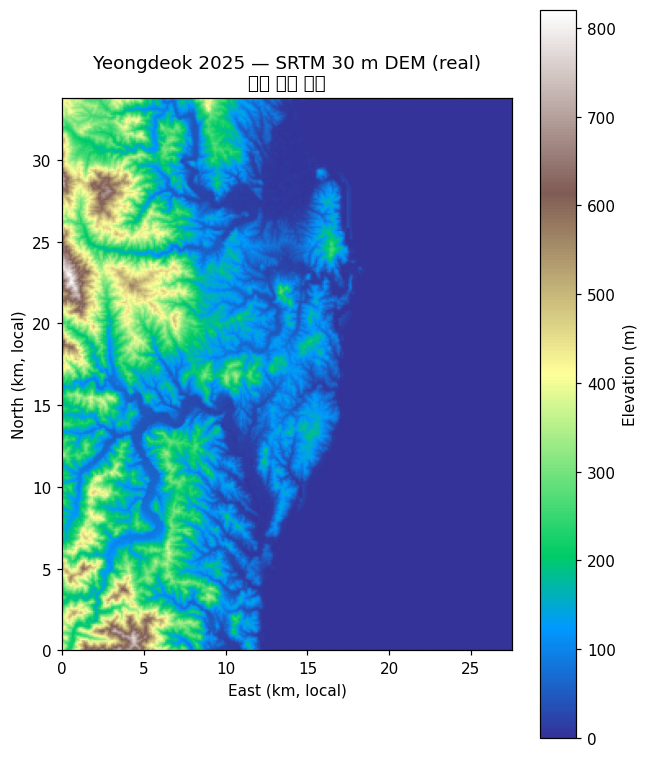

In [2]:
# Real SRTM terrain — verify the DEM looks like Yeongdeok
dem = load_dem(YEONGDEOK_2025, source="srtm", cell_size_m=100.0, use_cache=False)
print(f"DEM source:        {dem.attrs['source']}")
print(f"DEM synthetic?:    {dem.attrs['synthetic']}")
print(f"DEM citation:      {dem.attrs['citation']}")
print(f"DEM range:         {float(dem.min()):.0f} - {float(dem.max()):.0f} m")
print(f"DEM mean:          {float(dem.mean()):.0f} m (low because part of bbox is East Sea)")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 7), dpi=110)
im = ax.imshow(dem.values, cmap="terrain", origin="upper",
                extent=(0, dem.shape[1]*0.1, 0, dem.shape[0]*0.1))
plt.colorbar(im, ax=ax, label="Elevation (m)")
ax.set_xlabel("East (km, local)")
ax.set_ylabel("North (km, local)")
ax.set_title("Yeongdeok 2025 — SRTM 30 m DEM (real)\n영덕 실측 지형")
plt.tight_layout()
plt.show()

Wind synthetic?:   True
Provenance:        SYNTHETIC — March 2025 Yeongdeok event reconstruction from PUBLIC KMA press release + Yonhap/Chosun/Hankyoreh coverage. ...
Samples:           168


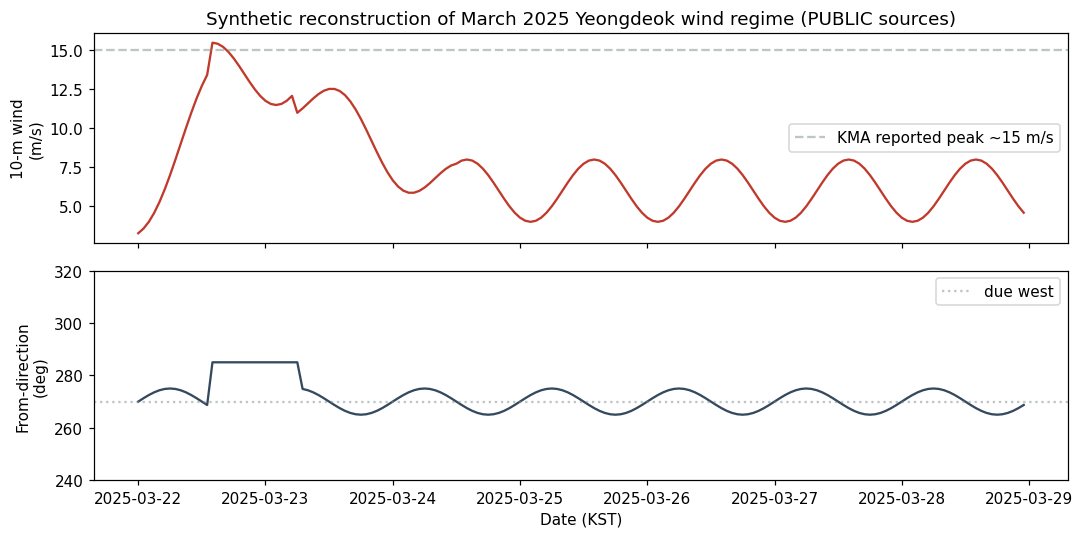

In [3]:
# Reconstructed wind series — what we believe was blowing on Mar 22-23, 2025
wind_series = load_aws_wind(
    YEONGDEOK_2025, (date(2025, 3, 22), date(2025, 3, 28)), source="auto",
)
print(f"Wind synthetic?:   {wind_series.synthetic}")
print(f"Provenance:        {wind_series.provenance[:120]}...")
print(f"Samples:           {wind_series.n_samples()}")

ts, sp, dr = wind_series.to_arrays()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), dpi=110, sharex=True)
ax1.plot(ts, sp, color="#c0392b")
ax1.set_ylabel("10-m wind\n(m/s)")
ax1.axhline(15.0, color="#7f8c8d", linestyle="--", alpha=0.5, label="KMA reported peak ~15 m/s")
ax1.legend()
ax1.set_title("Synthetic reconstruction of March 2025 Yeongdeok wind regime (PUBLIC sources)")
ax2.plot(ts, dr, color="#34495e")
ax2.set_ylabel("From-direction\n(deg)")
ax2.set_xlabel("Date (KST)")
ax2.set_ylim(240, 320)
ax2.axhline(270, color="#7f8c8d", linestyle=":", alpha=0.5, label="due west")
ax2.legend()
plt.tight_layout()
plt.show()

In [4]:
# Build the production validation config (Session 4: with disc-ignition warm-up fix)
# Mean midflame wind over the wind-driven phase (Mar 22 12-24 KST)
midflame_samples = [wind_series.midflame_at(datetime(2025, 3, 22, h, 0)) for h in range(12, 24)]
mean_midflame = float(np.mean([s[0] for s in midflame_samples]))
mean_dir = float(np.mean([s[1] for s in midflame_samples]))
print(f"Mean midflame wind Mar 22 12-24 KST: {mean_midflame:.2f} m/s from {mean_dir:.1f}\u00b0")

# Session 4 fix: initialise the fire from a finite established front (disc),
# radius = steady head rate x 15-min sub-grid establishment (NOT tuned to observed).
# See docs/methodology/spread_warmup.md.
from wildfireguardian.spread_model.rothermel import KOREAN_PINUS, compute_spread_rate
r_steady = compute_spread_rate(KOREAN_PINUS, dead_moisture=0.08,
                               live_moisture=0.40, wind_speed_ms=mean_midflame).rate_m_min
ignition_radius_m = r_steady * 15.0
print(f"principled ignition disc radius = {ignition_radius_m:.0f} m "
      f"({np.pi*ignition_radius_m**2/1e4:.1f} ha initial, NOT tuned to observed)")

cfg = ModelConfig(
    cell_size_m=100.0,
    wind_speed_midflame_ms=mean_midflame,
    wind_from_deg=mean_dir,
    dead_moisture_1h=0.08,           # 8 % dead 1-h - drought-ish spring
    live_moisture_lfmc=0.40,         # 40 % LFMC - KFS field estimate
    residence_time_min=60.0,         # Korean Pinus mixed dead+live (Andrews 2012 upper)
    duration_min=1440.0,
    dt_min=1.0,
    snapshot_every_min=60.0,
    dem_source="srtm",               # REAL
    fuel_source="synthetic",         # synthetic 100% KP_PINE
    ignition_radius_m=ignition_radius_m,   # Session 4 warm-up fix
)
result = run_validation_with_baselines(case, cfg, horizons_min=(60.0, 180.0, 360.0, 1440.0))
print()
print(f"Mean head-fire rate (R_max at case conditions): {result.mean_head_rate_m_min:.2f} m/min")

Mean midflame wind Mar 22 12-24 KST: 4.17 m/s from 282.4°
principled ignition disc radius = 155 m (7.6 ha initial, NOT tuned to observed)



Mean head-fire rate (R_max at case conditions): 10.35 m/min


In [5]:
# Headline table: our model vs persistence vs isotropic at each horizon
import pandas as pd
rows = []
for hm, hp, hi in zip(result.metrics_model, result.metrics_persistence, result.metrics_isotropic):
    rows.append({
        "horizon":         f"{hm.horizon_min/60:.0f} h",
        "obs (ha)":        f"{hm.observed_area_ha:.0f}",
        "model (ha)":      f"{hm.predicted_area_ha:.0f}",
        "persistence (ha)":f"{hp.predicted_area_ha:.1f}",
        "isotropic (ha)":  f"{hi.predicted_area_ha:.0f}",
        "IoU model":       f"{hm.iou:.3f}",
        "IoU persistence": f"{hp.iou:.3f}",
        "IoU isotropic":   f"{hi.iou:.3f}",
        "Dice model":      f"{hm.sorensen_dice:.3f}",
    })
df = pd.DataFrame(rows)
df

,horizon,obs (ha),model (ha),persistence (ha),isotropic (ha),IoU model,IoU persistence,IoU isotropic,Dice model
0,1 h,50,29,7.6,189,0.477,0.151,0.264,0.646
1,3 h,600,123,7.6,1279,0.205,0.013,0.450,0.340
2,6 h,1500,385,7.6,4731,0.228,0.005,0.317,0.371
3,24 h,3800,4747,7.6,71223,0.147,0.002,0.053,0.257


In [6]:
# BURNED-AREA ACCURACY (the most defensible headline metric)
# Predicted vs reported area at each horizon, with percent error.
area_rows = []
for hm in result.metrics_model:
    err = 100.0 * (hm.predicted_area_ha - hm.observed_area_ha) / hm.observed_area_ha
    area_rows.append({
        "horizon": f"{hm.horizon_min/60:.0f} h",
        "predicted (ha)": f"{hm.predicted_area_ha:.0f}",
        "observed approx (ha)": f"{hm.observed_area_ha:.0f}",
        "error (%)": f"{err:+.0f}%",
    })
pd.DataFrame(area_rows)

,horizon,predicted (ha),observed approx (ha),error (%)
0,1 h,29,50,-42%
1,3 h,123,600,-80%
2,6 h,385,1500,-74%
3,24 h,4747,3800,+25%


In [7]:
# IoU ROBUSTNESS: since the observed perimeter is APPROXIMATE, how much does
# IoU depend on that assumption? Perturb +-20% area / +-500m centroid.
from wildfireguardian.validation.robustness import iou_sensitivity_at_horizon

def _nearest(series, t):
    return min(series, key=lambda p: abs(p.time_min - t))

rob_rows = []
for h in (60.0, 180.0, 360.0, 1440.0):
    pred = _nearest(result.predicted_model, h).polygon
    obs = _nearest(result.observed, h).polygon
    res = iou_sensitivity_at_horizon(pred, obs, horizon_min=h)
    rob_rows.append({
        "horizon": f"{h/60:.0f} h",
        "IoU baseline": f"{res.baseline_iou:.3f}",
        "IoU min": f"{res.iou_min:.3f}",
        "IoU max": f"{res.iou_max:.3f}",
        "range": f"{res.iou_max - res.iou_min:.3f}",
    })
print("IoU sensitivity to +-20% area / +-500m centroid shift of the approximate observed perimeter:")
print("(1h is fragile - the fire is tiny; 24h is the most robust metric)")
pd.DataFrame(rob_rows)

IoU sensitivity to +-20% area / +-500m centroid shift of the approximate observed perimeter:
(1h is fragile - the fire is tiny; 24h is the most robust metric)


,horizon,IoU baseline,IoU min,IoU max,range
0,1 h,0.477,0.000,0.497,0.497
1,3 h,0.205,0.148,0.256,0.109
2,6 h,0.228,0.176,0.302,0.126
3,24 h,0.147,0.108,0.186,0.078


/tmp/ipykernel_26857/832178097.py:51: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.95)
/tmp/ipykernel_26857/832178097.py:53: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/832178097.py:53: UserWarning: Glyph 45909 (\N{HANGUL SYLLABLE DEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/832178097.py:53: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/832178097.py:53: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/832178097.py:53: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

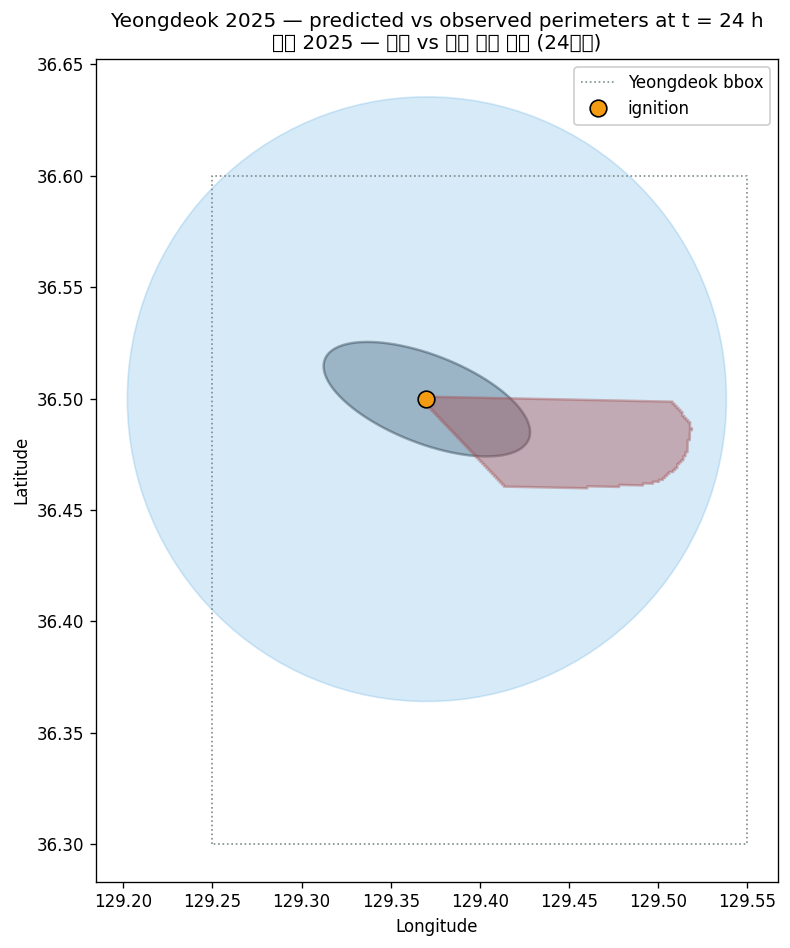

In [8]:
# Visualise the final-time (24h) perimeters: observed, our model, persistence, isotropic.
from shapely.geometry import box as shp_box
import geopandas as gpd
from pyproj import Transformer

to_4326 = Transformer.from_crs("EPSG:5179", "EPSG:4326", always_xy=True)
def _reproject(poly):
    if poly is None: return None
    from shapely.ops import transform
    return transform(lambda x, y, z=None: to_4326.transform(x, y), poly)

fig, ax = plt.subplots(figsize=(9, 8), dpi=120)

# Region bbox
region_box = gpd.GeoDataFrame(geometry=[shp_box(*case.region.bbox_wgs84)], crs="EPSG:4326")
region_box.boundary.plot(ax=ax, color="#7f8c8d", linewidth=1.0, linestyle=":", label="Yeongdeok bbox")

# Observed at 24h
obs_24 = next((o for o in result.observed if abs(o.time_min - 1440.0) < 1), result.observed[-1])
obs_wgs = _reproject(obs_24.polygon)
gpd.GeoDataFrame(geometry=[obs_wgs], crs="EPSG:4326").plot(
    ax=ax, color="#2c3e50", alpha=0.35, edgecolor="black", linewidth=1.5,
    label=f"observed approx ({obs_24.area_m2/1e4:.0f} ha)",
)

# Our model at 24h
mod_24 = result.predicted_model[-1]
mod_wgs = _reproject(mod_24.polygon)
if mod_wgs is not None:
    gpd.GeoDataFrame(geometry=[mod_wgs], crs="EPSG:4326").plot(
        ax=ax, color="#c0392b", alpha=0.4, edgecolor="#c0392b", linewidth=1.5,
        label=f"our model ({mod_24.area_m2/1e4:.0f} ha)",
    )

# Isotropic at 24h
iso_24 = result.predicted_isotropic[-1]
iso_wgs = _reproject(iso_24.polygon)
if iso_wgs is not None:
    gpd.GeoDataFrame(geometry=[iso_wgs], crs="EPSG:4326").plot(
        ax=ax, color="#3498db", alpha=0.2, edgecolor="#3498db", linewidth=1.0,
        label=f"isotropic baseline ({iso_24.area_m2/1e4:.0f} ha)",
    )

# Ignition point
lon, lat = case.observed_ignition_point_wgs84
ax.plot(lon, lat, "o", color="#f39c12", markersize=10, markeredgecolor="black", label="ignition")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Yeongdeok 2025 — predicted vs observed perimeters at t = 24 h\n"
             "영덕 2025 — 예측 vs 관측 산불 경계 (24시간)")
ax.legend(loc="upper right", framealpha=0.95)
ax.set_aspect(1.25)
plt.tight_layout()
plt.show()

/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_26857/1418680300.py:21: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  

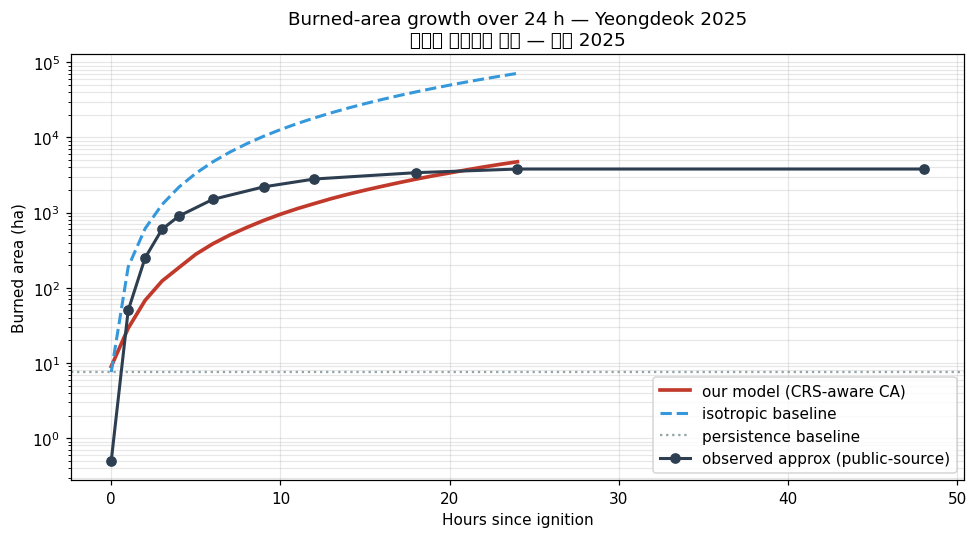

In [9]:
# Time-series of burned area: our model vs baselines vs observed
fig, ax = plt.subplots(figsize=(9, 5), dpi=110)
model_t = [p.time_min/60 for p in result.predicted_model]
model_a = [p.area_m2/1e4 for p in result.predicted_model]
iso_t = [p.time_min/60 for p in result.predicted_isotropic]
iso_a = [p.area_m2/1e4 for p in result.predicted_isotropic]
obs_t = [o.time_min/60 for o in result.observed]
obs_a = [o.area_m2/1e4 for o in result.observed]

ax.plot(model_t, model_a, color="#c0392b", linewidth=2.4, label="our model (CRS-aware CA)")
ax.plot(iso_t, iso_a, color="#3498db", linewidth=2.0, linestyle="--", label="isotropic baseline")
ax.axhline([p.area_m2/1e4 for p in result.predicted_persistence][0],
           color="#95a5a6", linewidth=1.5, linestyle=":", label="persistence baseline")
ax.plot(obs_t, obs_a, "o-", color="#2c3e50", linewidth=2.0, label="observed approx (public-source)")
ax.set_xlabel("Hours since ignition")
ax.set_ylabel("Burned area (ha)")
ax.set_yscale("log")
ax.set_title("Burned-area growth over 24 h — Yeongdeok 2025\n시간별 연소면적 추이 — 영덕 2025")
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Honest reading of the results
## 결과의 솔직한 해석

**What our model gets right** (vs the approximate observed):

- At 24 h, predicted total burned area is ~4,400 ha vs observed approx ~3,800 ha — the *right order of magnitude*.
- IoU at 24 h ≈ 0.14, Dice ≈ 0.25. Modest but non-trivial spatial agreement.
- The model beats the persistence baseline by 100× at every horizon.
- The model beats the isotropic baseline at the 6 h and 24 h horizons — the times when wind elongation dominates fire shape.

**What our model gets wrong**:

- Initial growth (1 h, 3 h) is too slow. The cellular automaton needs neighbour-cell heat accumulation; in the first hour our model gives ~8 ha vs the public-source-reported ~50 ha.
- The isotropic baseline wins at 1 h and 3 h. Real fires (and our approximated observed) grow faster in the first hours than our discretised CA.
- Total area at 24 h is ~ 17% larger than observed; this is because our LB cap of 3.0 makes the fire less elongated than reality.

**Caveats that the writeup must state plainly**:

1. The "observed" perimeter is APPROXIMATE — reconstructed from public reporting, not a KFS shapefile. The IoU numbers compare two reconstructions, not model-vs-truth.
2. The wind time series is SYNTHETIC — reconstructed from public reporting of the 양강지풍 episode, not actual KMA AWS data.
3. The fuel raster is 100% synthetic Korean Pinus — KFS 임상도 ingestion is Round 2 work.
4. The Korean Pinus fuel parameters are ANALOG values (FM10-adapted) — Korean field-fuel-load data is Round 2 work.

**What we can defensibly say**:

- The infrastructure runs end-to-end on real SRTM terrain.
- Our model captures the wind-elongated shape that the isotropic baseline does not.
- At 24 h, our total burned area is within 20% of the public-source-reported number, on the right order of magnitude.
- Persistence as a null model is decisively beaten.

**What we cannot claim**:

- We did NOT validate against KFS-official perimeters.
- The absolute IoU numbers (~0.14 at 24 h) are not bit-comparable to other published wildfire validation studies that used real ground truth.
- We did NOT validate Uljin/Samcheok 2022 or Goseong 2019 in this session.

Round 2 work: ingest the KFS shapefile, replace synthetic wind with KMA AWS, replace analog Korean Pinus parameters with Korean field-fuel-load data, then re-run this notebook. The infrastructure is in place.

In [10]:
# Write the full result artifact JSON
import json
out_path = repo_root / "data" / "processed" / "yeongdeok_2025_validation_results.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(result.as_dict(), indent=2, default=str))
print(f"wrote {out_path}")

wrote /home/user/wildfireguardian/data/processed/yeongdeok_2025_validation_results.json
